In [11]:
from sklearn.linear_model import LinearRegression, LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("Employee.csv")

df = pd.DataFrame(df)  

In [13]:
print(df.head())

        Name  Education  JoiningYear       City   Salary  PaymentTier  Age  \
0  Sanskriti  Bachelors         2017  Bangalore  77363.0            3   34   
1     Kartik  Bachelors         2013       Pune  69152.0            1   28   
2      Bindu  Bachelors         2014  New Delhi  80114.0            3   38   
3     Sudevi    Masters         2016  Bangalore  58618.0            3   27   
4       Joni    Masters         2017       Pune  87059.0            3   24   

   Gender EverBenched  ExperienceInCurrentDomain  LeaveOrNot  
0    Male          No                          0           0  
1  Female          No                          3           1  
2  Female          No                          2           0  
3    Male          No                          5           1  
4    Male         Yes                          2           1  


In [14]:
print(df.tail())

          Name  Education  JoiningYear       City   Salary  PaymentTier  Age  \
4648  Vishakha  Bachelors         2013  Bangalore  49850.0            3   26   
4649     Gross    Masters         2013       Pune  74690.0            2   37   
4650    Sewall    Masters         2018  New Delhi  78823.0            3   27   
4651    Conant  Bachelors         2012  Bangalore  72293.0            3   30   
4652    Clytie  Bachelors         2015  Bangalore  64703.0            3   33   

      Gender EverBenched  ExperienceInCurrentDomain  LeaveOrNot  
4648  Female          No                          4           0  
4649    Male          No                          2           1  
4650    Male          No                          5           1  
4651    Male         Yes                          2           0  
4652    Male         Yes                          4           0  


In [15]:
df.describe()

,JoiningYear,Salary,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4649.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,59752.191654,2.698259,29.393295,2.905652,0.343864
std,1.863377,17248.569545,0.561435,4.826087,1.558240,0.475047
min,2012.000000,30010.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,44816.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,59949.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,74302.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,89998.000000,3.000000,41.000000,7.000000,1.000000


In [16]:
df.isnull().sum()

Name                         0
Education                    3
JoiningYear                  0
City                         2
Salary                       4
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [17]:
df.fillna(value={'Education':'None' , 'City' : 'Unknown' , 'Salary':0} , inplace=True)

print(df.isnull().sum())

Name                         0
Education                    0
JoiningYear                  0
City                         0
Salary                       0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64


### GRAPH

city wise male and female

city wise total_salary


Text(0.5, 1.0, 'Total Salary by City')

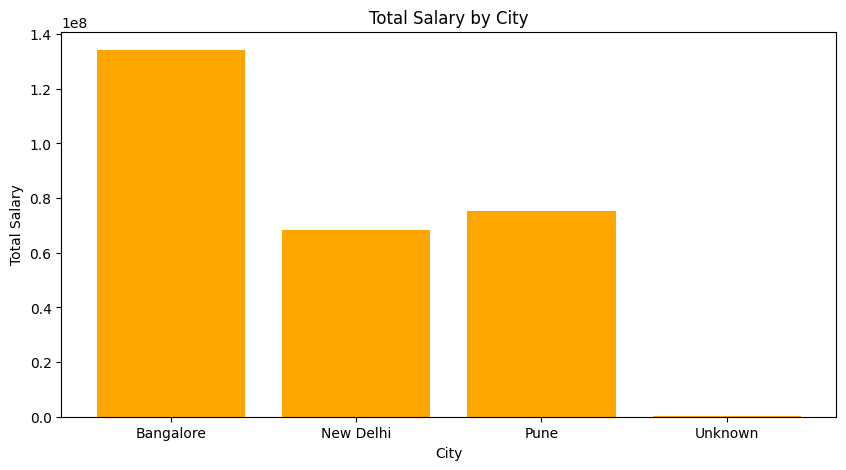

In [25]:
total_salary = df.groupby("City")["Salary"].sum().sort_index()

plt.figure(figsize=(10,5))
plt.bar(total_salary.index, total_salary.values , color='orange')
plt.xlabel('City')
plt.ylabel('Total Salary')
plt.title('Total Salary by City')



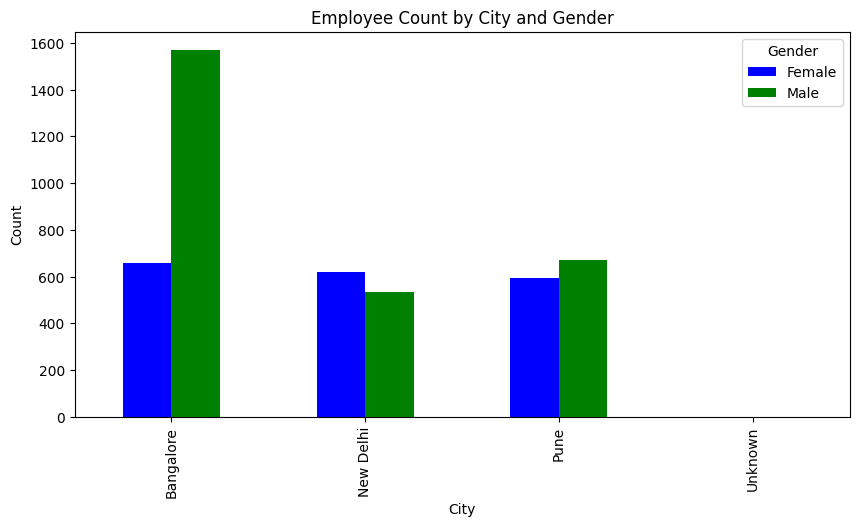

In [37]:
# male and female in city
gender_diff = df.groupby(['City', 'Gender']).size().unstack(fill_value=0)

gender_diff.plot(kind='bar', figsize=(10,5), color=['blue' , 'green'])
plt.xlabel('City')
plt.ylabel('Count')
plt.title('Employee Count by City and Gender')
plt.legend(title='Gender')


In [43]:
city_gender = df.groupby('Gender').value_counts()

city_gender = city_gender.reset_index(name = 'Count')

print(city_gender)

city_gender.plot(kind='bar', x='city_gender', y='Count', color=['blue' , 'green'], figsize=(10,5))

plt.show()



      Gender     Name  Education  JoiningYear       City   Salary  \
0     Female  Aarushi  Bachelors         2013  Bangalore  53282.0   
1     Female  Aarushi  Bachelors         2013  Bangalore  76910.0   
2     Female  Aarushi  Bachelors         2013       Pune  35929.0   
3     Female  Aarushi  Bachelors         2017       Pune  62677.0   
4     Female   Aastha  Bachelors         2012  Bangalore  83891.0   
...      ...      ...        ...          ...        ...      ...   
4648    Male   Zypern  Bachelors         2017       Pune  62258.0   
4649    Male    liebe  Bachelors         2015  Bangalore  70115.0   
4650    Male    liebe        PHD         2016  New Delhi  65774.0   
4651    Male   percer  Bachelors         2014  Bangalore  45541.0   
4652    Male   percer  Bachelors         2015  Bangalore  83942.0   

      PaymentTier  Age EverBenched  ExperienceInCurrentDomain  LeaveOrNot  \
0               1   27          No                          5           0   
1               3

KeyError: 'city_gender'